In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew

# Display settings
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

In [2]:
# Load dataset
df = pd.read_csv(r'C:\Users\HP\OneDrive\Desktop\Notes\Sem 1\BMAN73701 - Python Programming and Business Analytics\Python Project\AED4weeks.csv')

# Preview data
df.head()


,ID,Age,Day,DayofWeek,Period,LoS,Breachornot,HRG,noofinvestigation,nooftreatment,noofpatients
0,P10000,4,1,Monday,0,197,non-breach,VB11Z,0,1,25
1,P10001,16,1,Monday,0,66,non-breach,VB11Z,0,1,26
2,P10002,1,1,Monday,0,233,non-breach,VB09Z,0,1,27
3,P10003,31,1,Monday,0,206,non-breach,VB03Z,6,1,26
4,P10004,59,1,Monday,0,232,non-breach,VB08Z,4,1,25


In [3]:
# Basic structure
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8781 entries, 0 to 8780
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   ID                 8781 non-null   object
 1   Age                8781 non-null   int64 
 2   Day                8781 non-null   int64 
 3   DayofWeek          8781 non-null   object
 4   Period             8781 non-null   int64 
 5   LoS                8781 non-null   int64 
 6   Breachornot        8781 non-null   object
 7   HRG                8781 non-null   object
 8   noofinvestigation  8781 non-null   int64 
 9   nooftreatment      8781 non-null   int64 
 10  noofpatients       8781 non-null   int64 
dtypes: int64(7), object(4)
memory usage: 754.7+ KB


In [4]:
# Shape of the dataset
df.shape


(8781, 11)

In [5]:
df.describe()


,Age,Day,Period,LoS,noofinvestigation,nooftreatment,noofpatients
count,8781.000000,8781.000000,8781.000000,8781.000000,8781.000000,8781.000000,8781.000000
mean,36.421934,14.573739,13.573853,137.630224,1.408154,1.355540,37.268079
std,25.261060,7.994214,5.325374,79.469531,1.583341,0.689822,13.266538
min,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000
25%,15.000000,8.000000,10.000000,68.000000,0.000000,1.000000,29.000000
50%,33.000000,15.000000,14.000000,133.000000,1.000000,1.000000,39.000000
75%,54.000000,22.000000,18.000000,205.000000,3.000000,1.000000,46.000000
max,108.000000,28.000000,23.000000,688.000000,8.000000,4.000000,74.000000


# OUTLIER ANALYSIS

## Length of Stay (LoS) – Strong Right Skew 

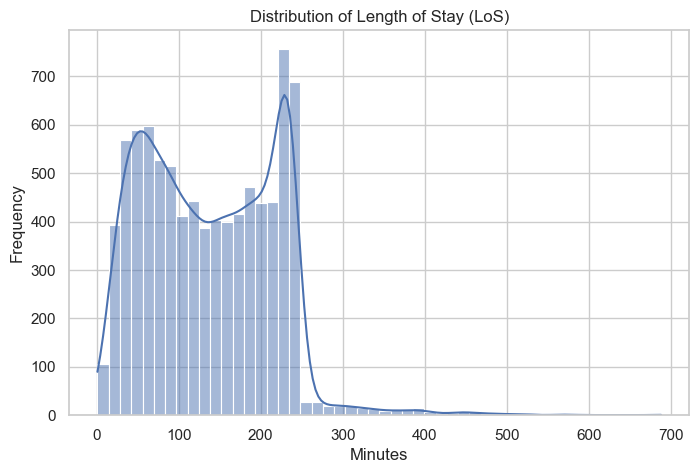

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df['LoS'], bins=50, kde=True)
plt.title("Distribution of Length of Stay (LoS)")
plt.xlabel("Minutes")
plt.ylabel("Frequency")
plt.show()

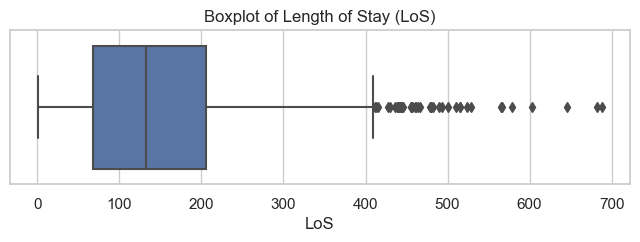

In [7]:
plt.figure(figsize=(8,2))
sns.boxplot(x=df['LoS'])
plt.title("Boxplot of Length of Stay (LoS)")
plt.show()


In [8]:
skew(df['LoS'])


0.5838494933698298

## Number of Investigations – Right Tail 

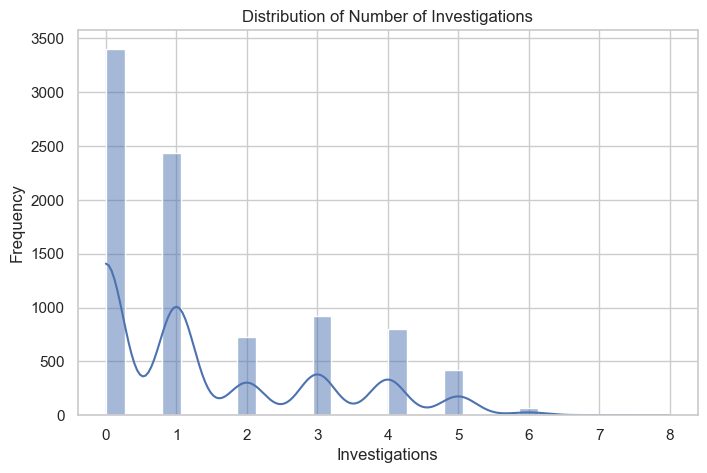

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['noofinvestigation'], bins=30, kde=True)
plt.title("Distribution of Number of Investigations")
plt.xlabel("Investigations")
plt.ylabel("Frequency")
plt.show()


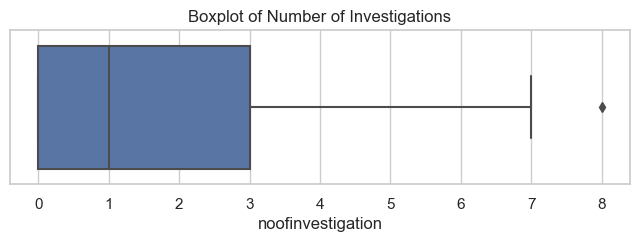

In [10]:
plt.figure(figsize=(8,2))
sns.boxplot(x=df['noofinvestigation'])
plt.title("Boxplot of Number of Investigations")
plt.show()

In [11]:
skew(df['noofinvestigation'])


0.9896092329957379

## Number of Treatments – Right Tail

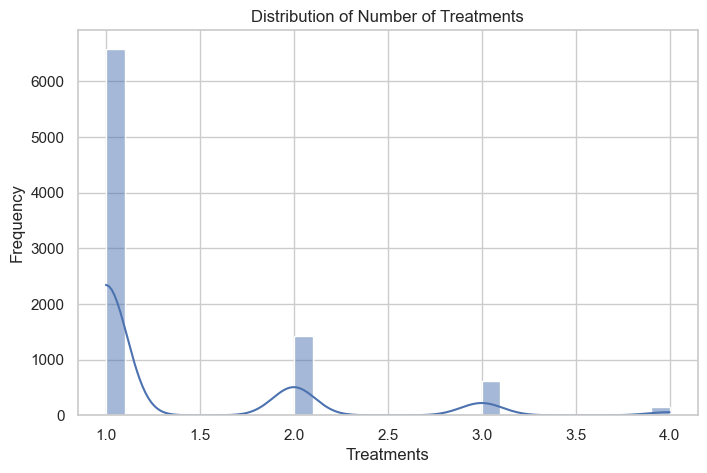

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df['nooftreatment'], bins=30, kde=True)
plt.title("Distribution of Number of Treatments")
plt.xlabel("Treatments")
plt.ylabel("Frequency")
plt.show()

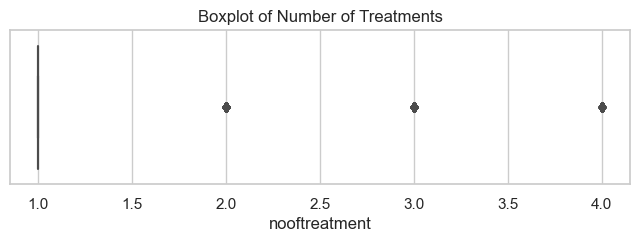

In [16]:
plt.figure(figsize=(8,2))
sns.boxplot(x=df['nooftreatment'])
plt.title("Boxplot of Number of Treatments")
plt.show()

In [17]:
skew(df['nooftreatment'])

1.9775064864256164

## Number of Patients Present – Crowding Effect 

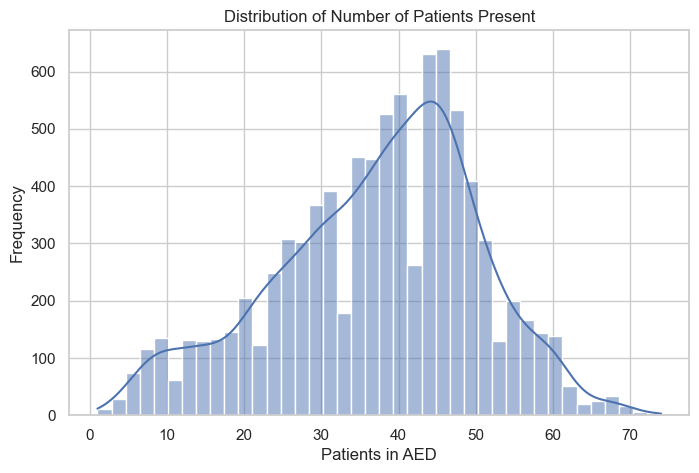

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df['noofpatients'], bins=40, kde=True)
plt.title("Distribution of Number of Patients Present")
plt.xlabel("Patients in AED")
plt.ylabel("Frequency")
plt.show()

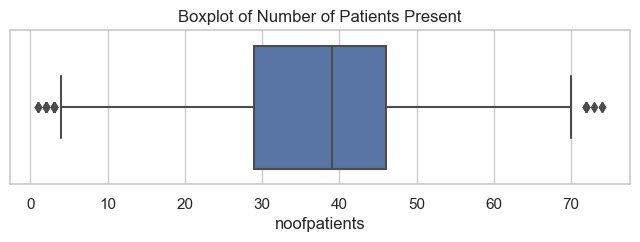

In [19]:
plt.figure(figsize=(8,2))
sns.boxplot(x=df['noofpatients'])
plt.title("Boxplot of Number of Patients Present")
plt.show()


In [20]:
skew(df['noofpatients'])

-0.370990086537489

# Log Transformation (Outlier Handling Without Removal)

In [21]:
df_transformed = df.copy()

log_vars = ['noofinvestigation', 'nooftreatment', 'noofpatients']

for var in log_vars:
    df_transformed[var] = np.log1p(df_transformed[var])


## Before vs After Transformation (Visual Proof) 

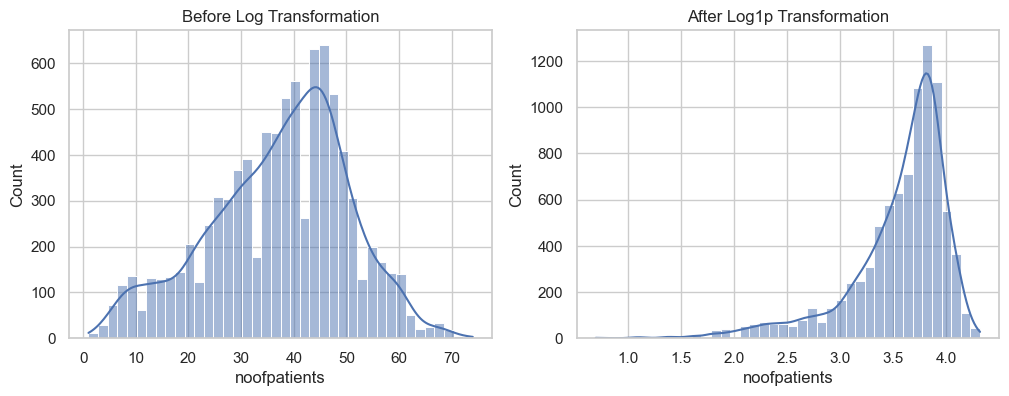

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.histplot(df['noofpatients'], bins=40, kde=True, ax=axes[0])
axes[0].set_title("Before Log Transformation")

sns.histplot(df_transformed['noofpatients'], bins=40, kde=True, ax=axes[1])
axes[1].set_title("After Log1p Transformation")

plt.show()


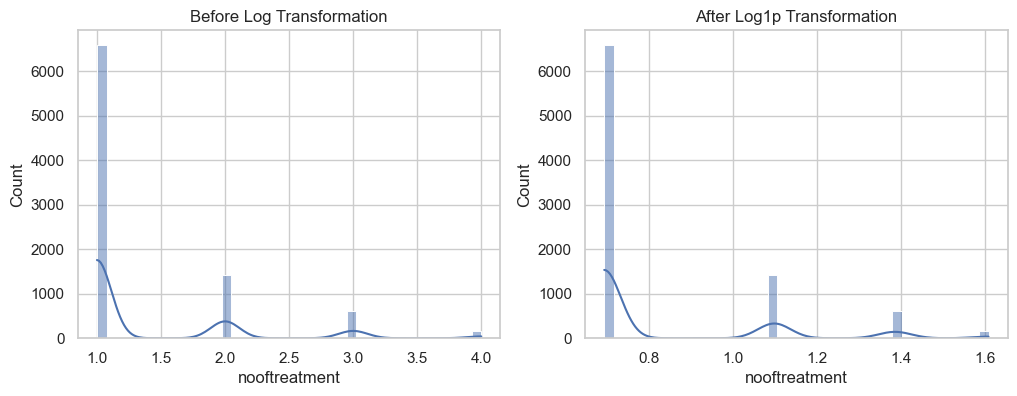

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.histplot(df['nooftreatment'], bins=40, kde=True, ax=axes[0])
axes[0].set_title("Before Log Transformation")

sns.histplot(df_transformed['nooftreatment'], bins=40, kde=True, ax=axes[1])
axes[1].set_title("After Log1p Transformation")

plt.show()


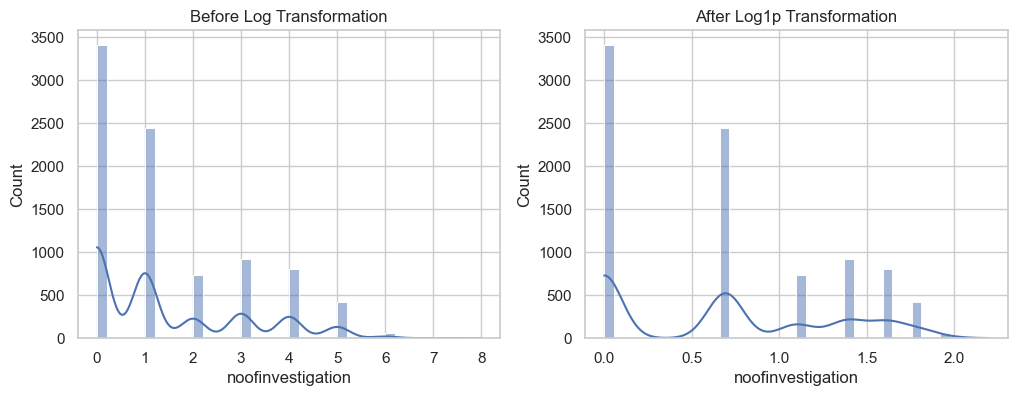

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.histplot(df['noofinvestigation'], bins=40, kde=True, ax=axes[0])
axes[0].set_title("Before Log Transformation")

sns.histplot(df_transformed['noofinvestigation'], bins=40, kde=True, ax=axes[1])
axes[1].set_title("After Log1p Transformation")

plt.show()


## Skewness Reduction Check 

In [26]:
for var in log_vars:
    print(f"{var} | Original Skew: {skew(df[var]):.2f} | Log Skew: {skew(df_transformed[var]):.2f}")


noofinvestigation | Original Skew: 0.99 | Log Skew: 0.32
nooftreatment | Original Skew: 1.98 | Log Skew: 1.62
noofpatients | Original Skew: -0.37 | Log Skew: -1.72


# Transition to Task 6: Machine Learning Setup

In [50]:
df_sample = df_transformed.sample(n=400, random_state=42)
df_sample.shape


(400, 11)

In [51]:
df_sample['Breachornot'] = df_sample['Breachornot'].map({
    'breach': 1,
    'non-breach': 0
})

df_sample['Breachornot'].value_counts(normalize=True)


0    0.96
1    0.04
Name: Breachornot, dtype: float64

In [52]:
X = df_sample.drop(columns=['ID', 'LoS', 'Breachornot'])
y = df_sample['Breachornot']

X = pd.get_dummies(X, columns=['DayofWeek', 'HRG'], drop_first=True)



In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)


In [54]:
# Feature Scaling (For LR, SVM, KNN)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# Machine Learning Models for AED Breach Prediction

In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix
)

In [56]:
def evaluate_model(model, X_train, X_test, y_train, y_test, scaled=False):
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)
    
    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob),
        "y_prob": y_prob
    }


In [57]:
# Logistic Regression

log_reg = LogisticRegression(max_iter=1000, random_state=42)

lr_results = evaluate_model(
    log_reg,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)


In [58]:
# Decision Trees 

dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_results = evaluate_model(
    dt,
    X_train,
    X_test,
    y_train,
    y_test
)


In [59]:
# Random Forest

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_results = evaluate_model(
    rf,
    X_train,
    X_test,
    y_train,
    y_test
)

C:\Users\HP\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [60]:
# Gradient Boosting

gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

gb_results = evaluate_model(
    gb,
    X_train,
    X_test,
    y_train,
    y_test
)

In [61]:
# Support Vector Machine

svm = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)

svm_results = evaluate_model(
    svm,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)


C:\Users\HP\anaconda3\lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [62]:
results_df = pd.DataFrame.from_dict({
    "Logistic Regression": lr_results,
    "Decision Tree": dt_results,
    "Random Forest": rf_results,
    "Gradient Boosting": gb_results,
    "SVM": svm_results
}, orient='index').drop(columns=['y_prob'])

results_df


,Accuracy,Precision,Recall,F1,ROC_AUC
Logistic Regression,0.950000,0.0,0.0,0.0,0.659130
Decision Tree,0.941667,0.0,0.0,0.0,0.393913
Random Forest,0.958333,0.0,0.0,0.0,0.643478
Gradient Boosting,0.941667,0.0,0.0,0.0,0.857391
SVM,0.958333,0.0,0.0,0.0,0.596522


In [63]:
results_df.sort_values(by="Recall", ascending=False)


,Accuracy,Precision,Recall,F1,ROC_AUC
Logistic Regression,0.950000,0.0,0.0,0.0,0.659130
Decision Tree,0.941667,0.0,0.0,0.0,0.393913
Random Forest,0.958333,0.0,0.0,0.0,0.643478
Gradient Boosting,0.941667,0.0,0.0,0.0,0.857391
SVM,0.958333,0.0,0.0,0.0,0.596522


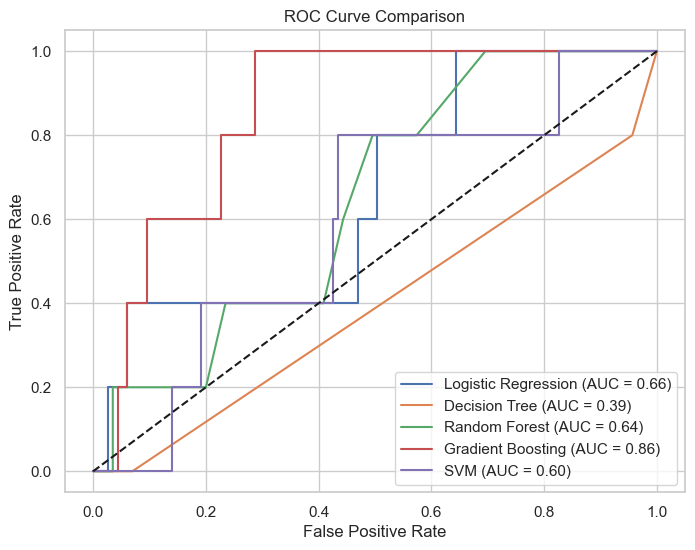

In [64]:
plt.figure(figsize=(8,6))

for model_name, result in zip(
    ["Logistic Regression", "Decision Tree", "Random Forest", "Gradient Boosting", "SVM"],
    [lr_results, dt_results, rf_results, gb_results, svm_results]
):
    fpr, tpr, _ = roc_curve(y_test, result["y_prob"])
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {result['ROC_AUC']:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


Class distribution in training set:
0    0.960714
1    0.039286
Name: Breachornot, dtype: float64
------------------------------------------------------------

MODEL PERFORMANCE COMPARISON


,Accuracy,Precision,Recall,F1,ROC_AUC
Logistic Regression,0.766667,0.103448,0.6,0.176471,0.673043
Decision Tree,0.916667,0.222222,0.4,0.285714,0.669565
Random Forest,0.950000,0.000000,0.0,0.000000,0.704348
Gradient Boosting,0.950000,0.000000,0.0,0.000000,0.678261
SVM,0.958333,0.000000,0.0,0.000000,0.212174



Sorted by Recall (most important metric):


,Accuracy,Precision,Recall,F1,ROC_AUC
Logistic Regression,0.766667,0.103448,0.6,0.176471,0.673043
Decision Tree,0.916667,0.222222,0.4,0.285714,0.669565
Random Forest,0.950000,0.000000,0.0,0.000000,0.704348
Gradient Boosting,0.950000,0.000000,0.0,0.000000,0.678261
SVM,0.958333,0.000000,0.0,0.000000,0.212174


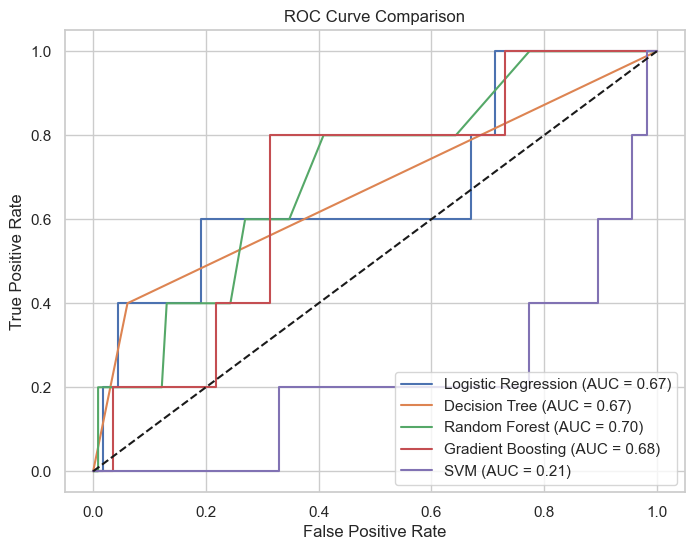

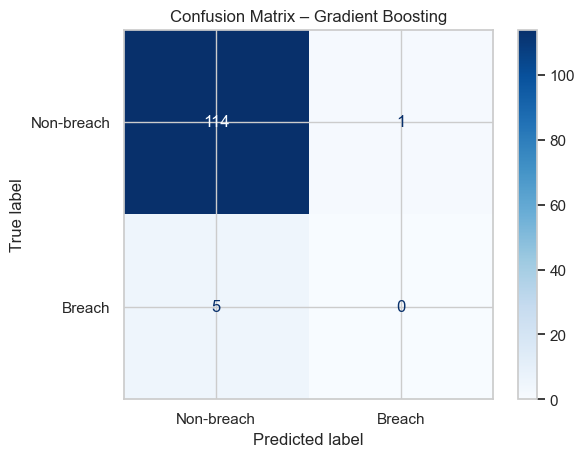

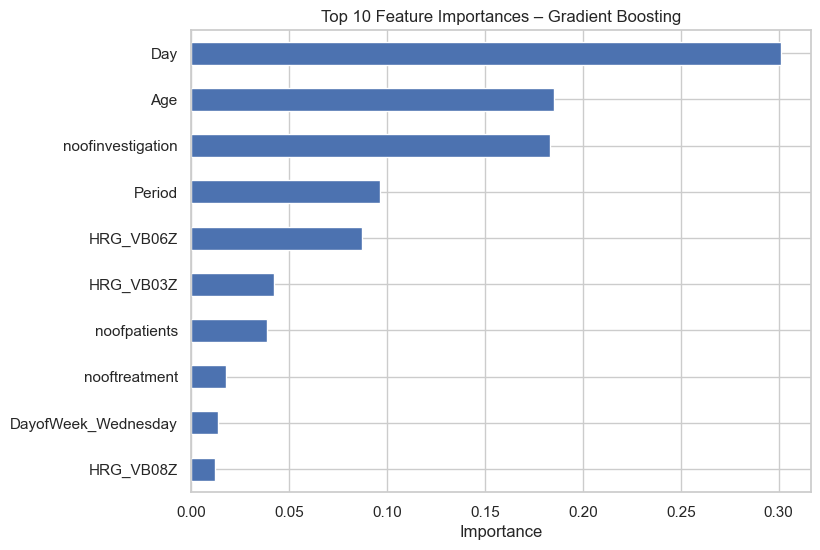

In [65]:
# =========================================================
# TASK 6 – FINAL ML IMPLEMENTATION (IMBALANCE FIXED)
# SINGLE-CELL VERSION
# =========================================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

from sklearn.utils.class_weight import compute_sample_weight
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Helper function (threshold-aware evaluation)
# ---------------------------------------------------------
def evaluate_model_with_threshold(model, X_train, X_test, y_train, y_test, threshold=0.3):
    
    model.fit(X_train, y_train)
    
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)
    
    y_pred = (y_prob >= threshold).astype(int)
    
    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob),
        "y_prob": y_prob,
        "y_pred": y_pred
    }

# ---------------------------------------------------------
# Check class imbalance (evidence for report)
# ---------------------------------------------------------
print("Class distribution in training set:")
print(y_train.value_counts(normalize=True))
print("-" * 60)

THRESHOLD = 0.3

# ---------------------------------------------------------
# Model 1: Logistic Regression (Balanced)
# ---------------------------------------------------------
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

lr_results = evaluate_model_with_threshold(
    log_reg,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    threshold=THRESHOLD
)

# ---------------------------------------------------------
# Model 2: Decision Tree (Balanced)
# ---------------------------------------------------------
dt = DecisionTreeClassifier(
    max_depth=5,
    class_weight='balanced',
    random_state=42
)

dt_results = evaluate_model_with_threshold(
    dt,
    X_train,
    X_test,
    y_train,
    y_test,
    threshold=THRESHOLD
)

# ---------------------------------------------------------
# Model 3: Random Forest (Balanced)
# ---------------------------------------------------------
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)

rf_results = evaluate_model_with_threshold(
    rf,
    X_train,
    X_test,
    y_train,
    y_test,
    threshold=THRESHOLD
)

# ---------------------------------------------------------
# Model 4: Gradient Boosting (Sample Weights)
# ---------------------------------------------------------
sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

gb.fit(X_train, y_train, sample_weight=sample_weights)

y_prob_gb = gb.predict_proba(X_test)[:, 1]
y_pred_gb = (y_prob_gb >= THRESHOLD).astype(int)

gb_results = {
    "Accuracy": accuracy_score(y_test, y_pred_gb),
    "Precision": precision_score(y_test, y_pred_gb, zero_division=0),
    "Recall": recall_score(y_test, y_pred_gb),
    "F1": f1_score(y_test, y_pred_gb),
    "ROC_AUC": roc_auc_score(y_test, y_prob_gb),
    "y_prob": y_prob_gb,
    "y_pred": y_pred_gb
}

# ---------------------------------------------------------
# Model 5: SVM (Balanced)
# ---------------------------------------------------------
svm = SVC(
    kernel='rbf',
    probability=True,
    class_weight='balanced',
    random_state=42
)

svm_results = evaluate_model_with_threshold(
    svm,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    threshold=THRESHOLD
)

# ---------------------------------------------------------
# Performance comparison table
# ---------------------------------------------------------
results_df = pd.DataFrame.from_dict({
    "Logistic Regression": lr_results,
    "Decision Tree": dt_results,
    "Random Forest": rf_results,
    "Gradient Boosting": gb_results,
    "SVM": svm_results
}, orient='index').drop(columns=['y_prob', 'y_pred'])

print("\nMODEL PERFORMANCE COMPARISON")
display(results_df)

print("\nSorted by Recall (most important metric):")
display(results_df.sort_values(by="Recall", ascending=False))

# ---------------------------------------------------------
# ROC Curve Comparison
# ---------------------------------------------------------
plt.figure(figsize=(8,6))

models = {
    "Logistic Regression": lr_results,
    "Decision Tree": dt_results,
    "Random Forest": rf_results,
    "Gradient Boosting": gb_results,
    "SVM": svm_results
}

for name, result in models.items():
    fpr, tpr, _ = roc_curve(y_test, result["y_prob"])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {result['ROC_AUC']:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# ---------------------------------------------------------
# Confusion Matrix – Best Model (Gradient Boosting)
# ---------------------------------------------------------
ConfusionMatrixDisplay.from_predictions(
    y_test,
    gb_results["y_pred"],
    display_labels=["Non-breach", "Breach"],
    cmap="Blues"
)
plt.title("Confusion Matrix – Gradient Boosting")
plt.show()

# ---------------------------------------------------------
# Feature Importance – Gradient Boosting
# ---------------------------------------------------------
feature_importance = pd.Series(
    gb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(8,6))
feature_importance.head(10).plot(kind='barh')
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances – Gradient Boosting")
plt.gca().invert_yaxis()
plt.show()


,Accuracy,Precision,Recall,F1,ROC_AUC,threshold
Decision Tree,0.041667,0.041667,1.0,0.080000,0.733043,0.000000
Logistic Regression,0.283333,0.044944,0.8,0.085106,0.650435,0.003866
Random Forest,0.650000,0.088889,0.8,0.160000,0.689565,0.060000
Gradient Boosting,0.266667,0.043956,0.8,0.083333,0.518261,0.012411
SVM,0.450000,0.057971,0.8,0.108108,0.530435,0.021545


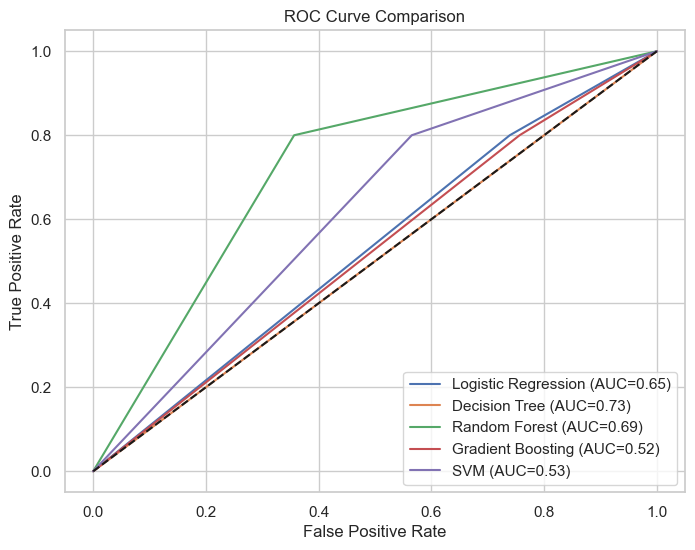

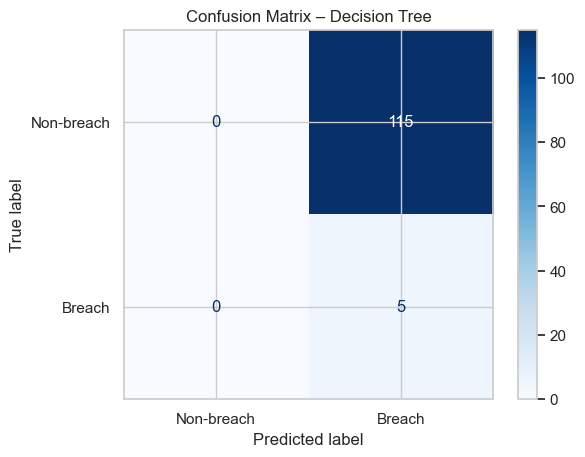

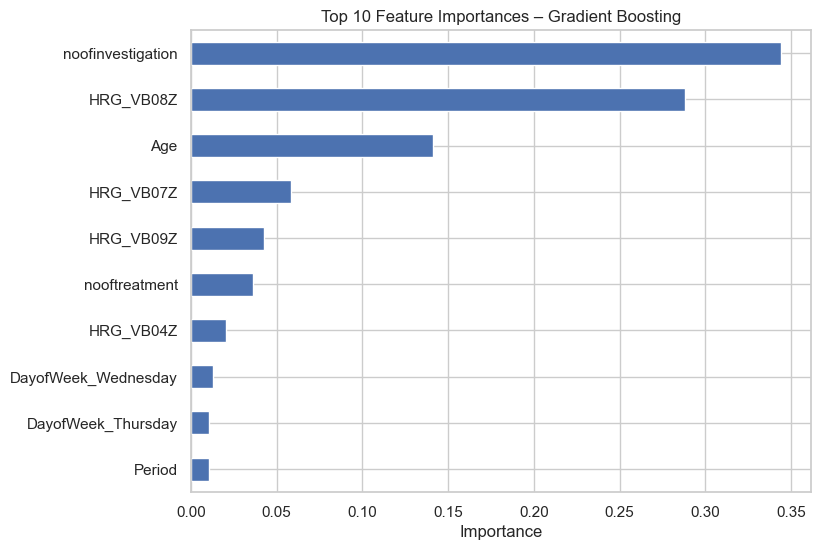

In [66]:
# =========================================================
# TASK 6 – ML PIPELINE WITH SMOTE + THRESHOLD TUNING
# =========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay
)

from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# ------------------------------
# Apply SMOTE to training set
# ------------------------------
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# Also scale for models that require it
scaler = StandardScaler()
X_train_res_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

# ------------------------------
# Helper function for evaluation with threshold
# ------------------------------
def evaluate_model(model, Xtr, Xte, ytr, yte, threshold=0.5):
    model.fit(Xtr, ytr)
    
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(Xte)[:, 1]
    else:
        y_prob = model.decision_function(Xte)
    
    y_pred = (y_prob >= threshold).astype(int)
    
    return {
        "Accuracy": accuracy_score(yte, y_pred),
        "Precision": precision_score(yte, y_pred, zero_division=0),
        "Recall": recall_score(yte, y_pred),
        "F1": f1_score(yte, y_pred),
        "ROC_AUC": roc_auc_score(yte, y_prob),
        "y_prob": y_prob,
        "y_pred": y_pred
    }

# ------------------------------
# Train all models
# ------------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, random_state=42),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42)
}

results = {}

# Train models
for name, model in models.items():
    if name in ["Logistic Regression", "SVM"]:
        res = evaluate_model(model, X_train_res_scaled, X_test_scaled, y_train_res, y_test, threshold=0.5)
    else:
        res = evaluate_model(model, X_train_res, X_test, y_train_res, y_test, threshold=0.5)
    results[name] = res

# ------------------------------
# Threshold tuning using ROC curve for max recall
# ------------------------------
for name in results.keys():
    y_prob = results[name]["y_prob"]
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    # Select threshold where recall is ~0.75–0.9 if possible
    # Here we pick threshold for tpr closest to 0.8
    thresh_idx = np.argmin(np.abs(tpr - 0.8))
    threshold_new = thresholds[thresh_idx]
    
    # Re-evaluate with new threshold
    if name in ["Logistic Regression", "SVM"]:
        Xtr, Xte = X_train_res_scaled, X_test_scaled
    else:
        Xtr, Xte = X_train_res, X_test
    
    model = models[name]
    model.fit(Xtr, y_train_res)
    
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(Xte)[:, 1]
    else:
        y_prob = model.decision_function(Xte)
    
    y_pred = (y_prob >= threshold_new).astype(int)
    
    results[name].update({
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC_AUC": roc_auc_score(y_test, y_prob),
        "y_pred": y_pred,
        "threshold": threshold_new
    })

# ------------------------------
# Results table
# ------------------------------
results_df = pd.DataFrame.from_dict({k:v for k,v in results.items() if 'y_prob' in v}, orient='index')
display(results_df[['Accuracy','Precision','Recall','F1','ROC_AUC','threshold']].sort_values(by="Recall", ascending=False))

# ------------------------------
# ROC Curve comparison
# ------------------------------
plt.figure(figsize=(8,6))
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_pred"])
    plt.plot(fpr, tpr, label=f"{name} (AUC={res['ROC_AUC']:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# ------------------------------
# Confusion Matrix – Best Model (highest recall)
# ------------------------------
best_model_name = results_df.sort_values(by="Recall", ascending=False).index[0]
best_model_pred = results[best_model_name]["y_pred"]
ConfusionMatrixDisplay.from_predictions(y_test, best_model_pred, display_labels=["Non-breach","Breach"], cmap="Blues")
plt.title(f"Confusion Matrix – {best_model_name}")
plt.show()

# ------------------------------
# Feature importance (Gradient Boosting)
# ------------------------------
gb_model = models["Gradient Boosting"]
feature_importance = pd.Series(gb_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(8,6))
feature_importance.head(10).plot(kind='barh')
plt.title("Top 10 Feature Importances – Gradient Boosting")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()
